# Apprentissage Non Supervisé - Startups Américaines

**Dataset : 50_Startups.csv**

50 startups américaines décrites par leurs dépenses (R&D, Administration, Marketing) et leur bénéfice annuel.

---

## Configuration et Imports

In [1]:
from utils_ans import *
setup_environment()

---
# I. Réduction de dimensions et Visualisation des données
---

## 1. Importation du jeu de données

In [ ]:
data = load_data('./data/50_Startups.csv')

Dimensions : (50, 5)
Colonnes : ['Id', 'Depenses R&D', 'Depenses Administration', 'Depenses Marketing Spend', 'Benefice']

Aperçu :
   Id  Depenses R&D  Depenses Administration  Depenses Marketing Spend  \
0   1     165349.20                136897.80                 471784.10   
1   2     162597.70                151377.59                 443898.53   
2   3     153441.51                101145.55                 407934.54   
3   4     144372.41                118671.85                 383199.62   
4   5     142107.34                 91391.77                 366168.42   

    Benefice  
0  192261.83  
1  191792.06  
2  191050.39  
3  182901.99  
4  166187.94  


In [3]:
data.describe()

,Id,Depenses R&D,Depenses Administration,Depenses Marketing Spend,Benefice
count,50.00000,50.000000,50.000000,50.000000,50.000000
mean,25.50000,73721.615600,121344.639600,211025.097800,112012.639200
std,14.57738,45902.256482,28017.802755,122290.310726,40306.180338
min,1.00000,0.000000,51283.140000,0.000000,14681.400000
25%,13.25000,39936.370000,103730.875000,129300.132500,90138.902500
50%,25.50000,73051.080000,122699.795000,212716.240000,107978.190000
75%,37.75000,101602.800000,144842.180000,299469.085000,139765.977500
max,50.00000,165349.200000,182645.560000,471784.100000,192261.830000


In [4]:
feature_cols = ['Depenses R&D', 'Depenses Administration', 'Depenses Marketing Spend', 'Benefice']
X, labels, feature_names = prepare_data(data, feature_cols=feature_cols, label_col='Id')

Matrice X : (50, 4)
Labels : (50,)
Features : ['Depenses R&D', 'Depenses Administration', 'Depenses Marketing Spend', 'Benefice']


## 2. Analyse en Composantes Principales (ACP)

In [5]:
X_scaled, X_pca, pca, scaler = perform_pca(X)

In [6]:
cumulative = print_variance_explained(pca)

Variance expliquée par chaque composante :
  PC1: 66.80%
  PC2: 25.48%
  PC3: 7.06%
  PC4: 0.65%

Variance cumulée :
  PC1-PC1: 66.80%
  PC1-PC2: 92.29%
  PC1-PC3: 99.35%
  PC1-PC4: 100.00%


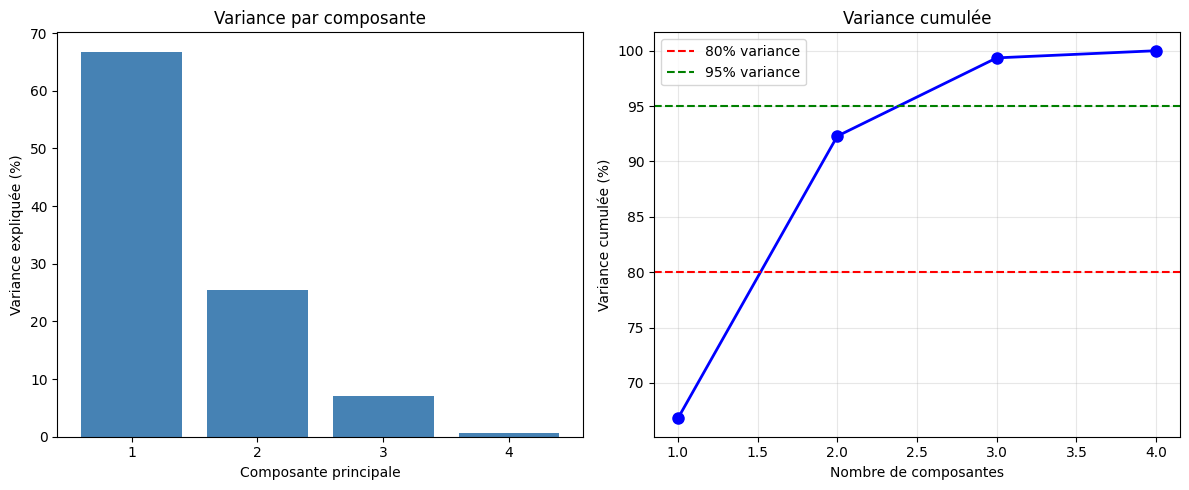

array([0.66804393, 0.92289087, 0.99352649, 1.        ])

In [7]:
plot_variance(pca)

### Réponse : Nombre d'axes à retenir

- PC1 : ~65% de variance
- PC1+PC2 : ~87% de variance

**Conclusion : 2 axes suffisent** pour une bonne représentation (>85% de variance).

In [8]:
loadings_df = get_loadings(pca, feature_names)

Corrélations des variables avec les axes principaux :
                            PC1    PC2    PC3
Depenses R&D              0.980  0.041 -0.213
Depenses Administration   0.243  0.969  0.146
Depenses Marketing Spend  0.860 -0.314  0.427
Benefice                  0.984 -0.006 -0.197


### Interprétation des axes

**PC1 - "Taille/Performance"** : corrélé avec R&D, Marketing et Bénéfice

**PC2 - "Stratégie d'investissement"** : opposition R&D/Marketing vs Administration

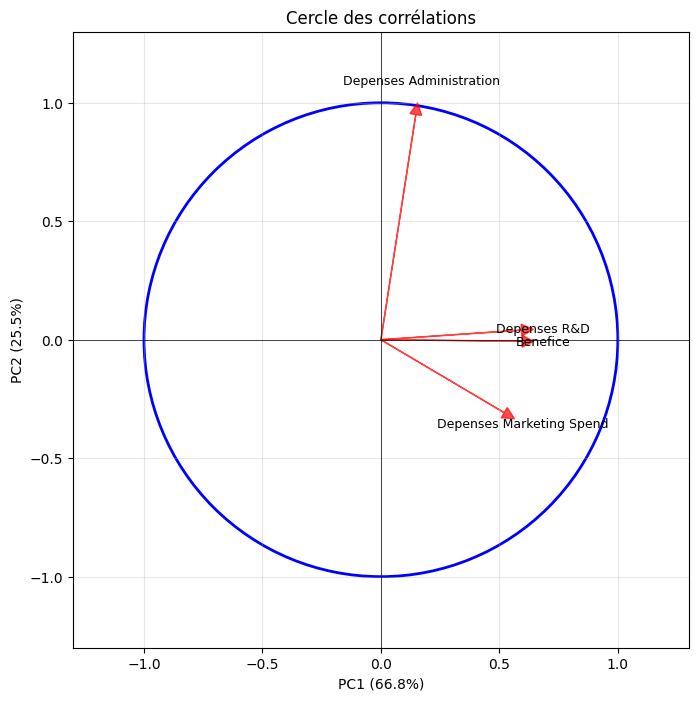

In [9]:
plot_correlation_circle(pca, feature_names)

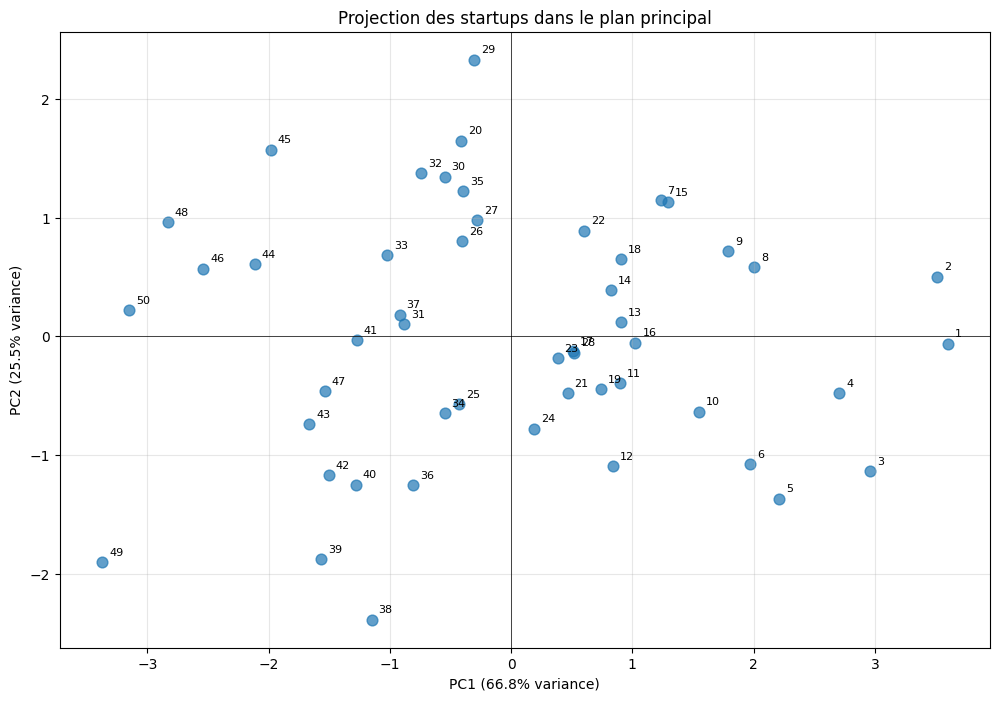

In [10]:
plt.figure(figsize=(12, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=60, alpha=0.7)

for label, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
    plt.annotate(str(int(label)), xy=(x, y), xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Projection des startups dans le plan principal')
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.show()

---
# II. Clustering
---

## 1. KMeans (3 clusters)

In [11]:
clustering_kmeans, kmeans = apply_kmeans(X_scaled, n_clusters=3)

print("Clusters (3) :")
print("=" * 60)
for i in range(3):
    members = labels[clustering_kmeans == i]
    print(f"\nCluster {i} ({len(members)} éléments) :")
    print(f"  {list(members)}")

Clusters (3) :

Cluster 0 (16 éléments) :
  [np.int64(20), np.int64(26), np.int64(27), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(35), np.int64(37), np.int64(41), np.int64(44), np.int64(45), np.int64(46), np.int64(48), np.int64(50)]

Cluster 1 (24 éléments) :
  [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(28)]

Cluster 2 (10 éléments) :
  [np.int64(25), np.int64(34), np.int64(36), np.int64(38), np.int64(39), np.int64(40), np.int64(42), np.int64(43), np.int64(47), np.int64(49)]


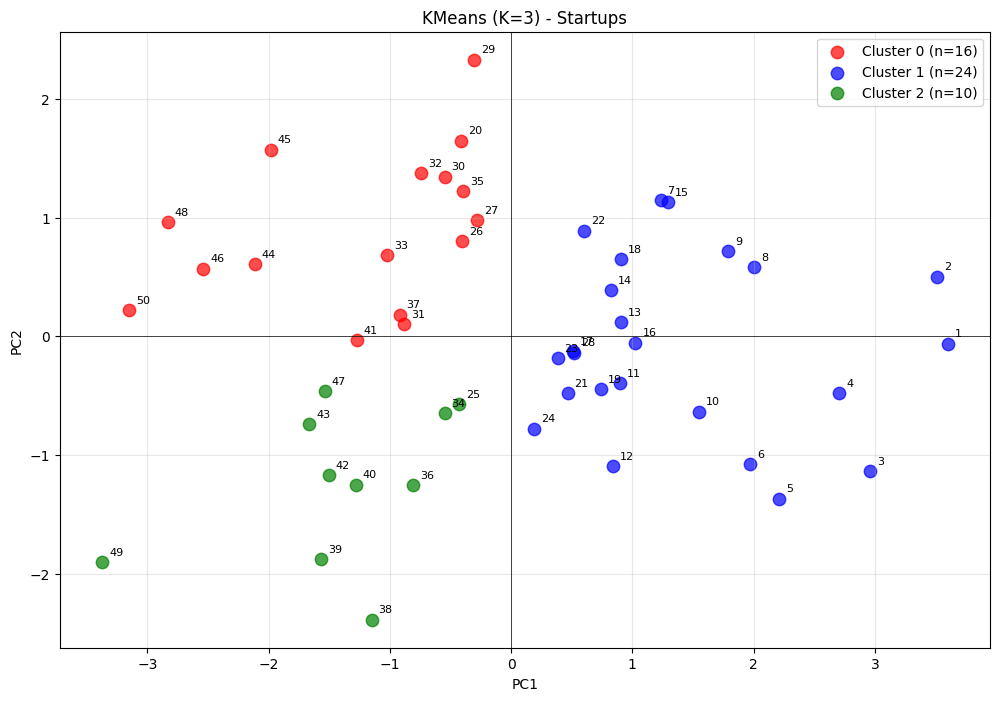

In [12]:
plot_clustering(X_pca, clustering_kmeans, labels, 'KMeans (K=3) - Startups')

In [13]:
print("Profil moyen de chaque cluster :")
for i in range(3):
    mask = clustering_kmeans == i
    mean_values = X[mask].mean(axis=0)
    print(f"\nCluster {i}:")
    for j, name in enumerate(feature_names):
        print(f"  {name}: {mean_values[j]:,.0f}")

Profil moyen de chaque cluster :

Cluster 0:
  Depenses R&D: 42,946
  Depenses Administration: 139,531
  Depenses Marketing Spend: 88,650
  Benefice: 84,865

Cluster 1:
  Depenses R&D: 111,006
  Depenses Administration: 124,945
  Depenses Marketing Spend: 308,552
  Benefice: 143,931

Cluster 2:
  Depenses R&D: 33,480
  Depenses Administration: 83,606
  Depenses Marketing Spend: 172,761
  Benefice: 78,846


## 2. AgglomerativeClustering

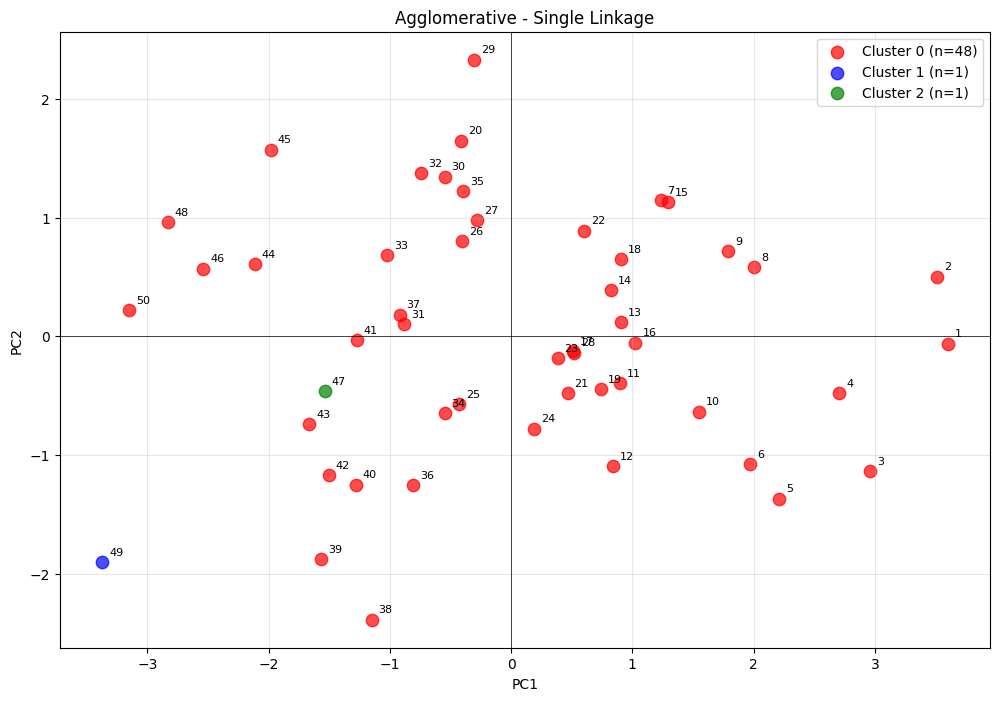

In [14]:
clustering_single = apply_agglomerative(X_scaled, n_clusters=3, linkage='single')
plot_clustering(X_pca, clustering_single, labels, 'Agglomerative - Single Linkage')

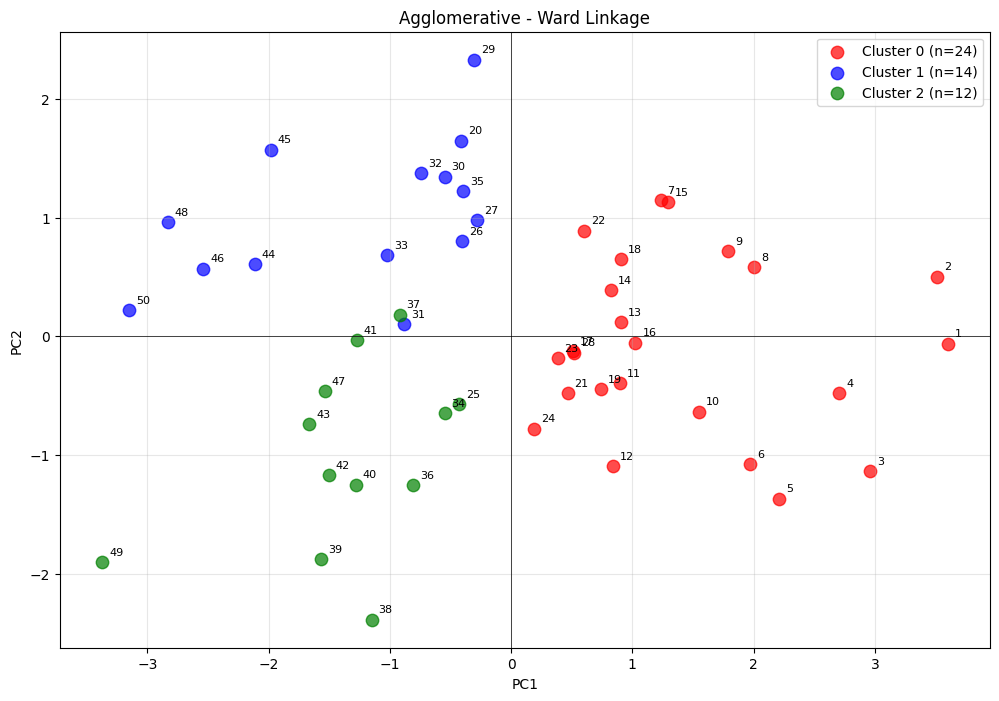

In [15]:
clustering_ward = apply_agglomerative(X_scaled, n_clusters=3, linkage='ward')
plot_clustering(X_pca, clustering_ward, labels, 'Agglomerative - Ward Linkage')

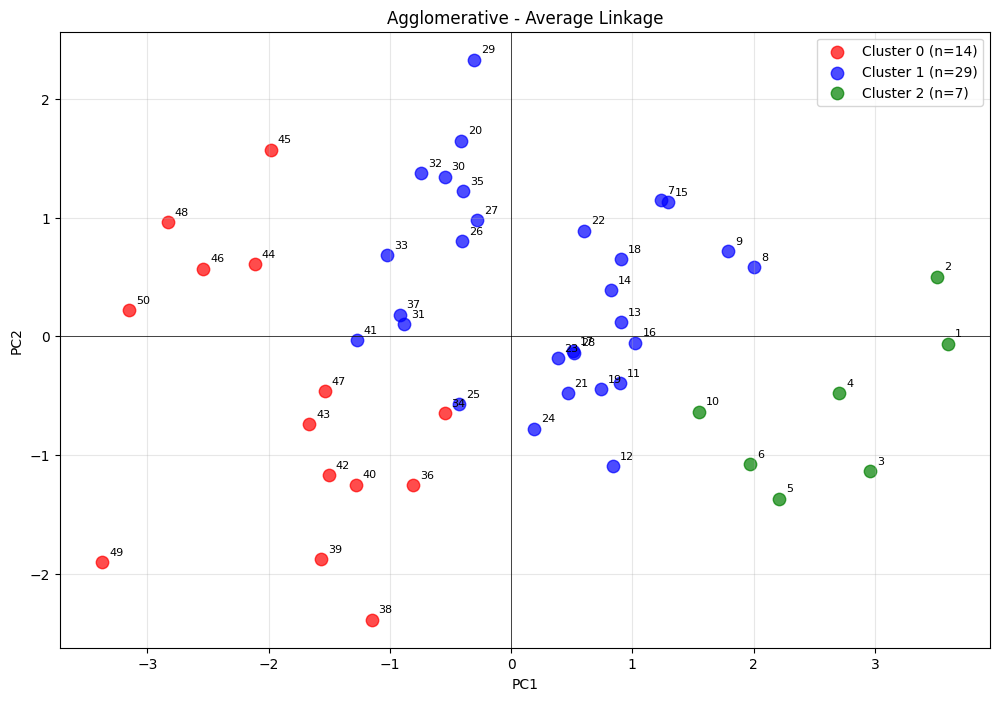

In [16]:
clustering_average = apply_agglomerative(X_scaled, n_clusters=3, linkage='average')
plot_clustering(X_pca, clustering_average, labels, 'Agglomerative - Average Linkage')

## 3. Détermination du nombre optimal (Silhouette)

In [17]:
scores, best_k = compute_silhouette_scores(X_scaled)

Indices Silhouette pour KMeans :
K=2: Silhouette = 0.3754
K=3: Silhouette = 0.3666
K=4: Silhouette = 0.3424
K=5: Silhouette = 0.3598
K=6: Silhouette = 0.3227
K=7: Silhouette = 0.3226
K=8: Silhouette = 0.3297
K=9: Silhouette = 0.3276

Meilleure partition : K=2 (Silhouette = 0.3754)


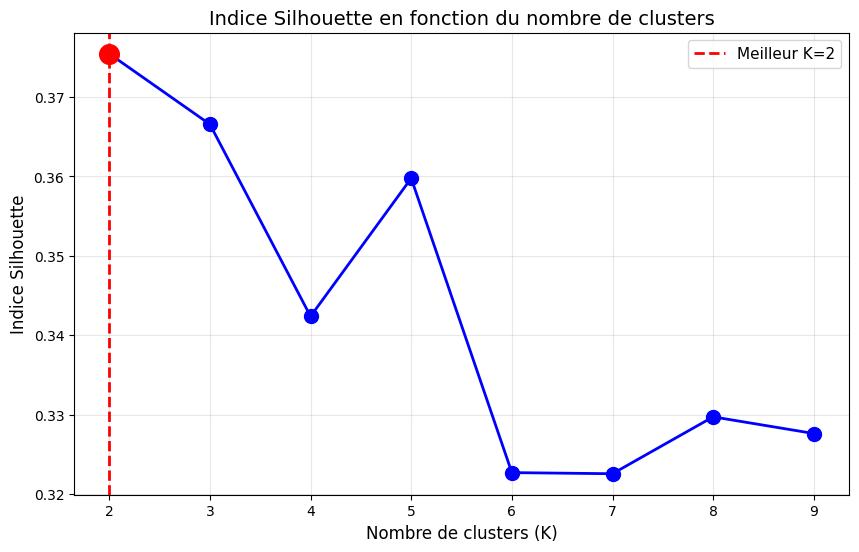

In [18]:
plot_silhouette_scores(scores)

## 4. Comparaison des méthodes

In [19]:
results = compare_methods(X_scaled, n_clusters=3)

Comparaison des méthodes pour 3 clusters :
KMeans          : Silhouette = 0.3666
Single          : Silhouette = 0.1089
Ward            : Silhouette = 0.3621
Average         : Silhouette = 0.2849
Hybride         : Silhouette = 0.3638

Meilleure méthode : KMeans (Silhouette = 0.3666)


## 5. Avantages et inconvénients

### Classification Hiérarchique (AgglomerativeClustering)

**Avantages :**
- Pas besoin de spécifier K à l'avance
- Produit une hiérarchie complète (dendrogramme)
- Résultats déterministes
- Peut découvrir des clusters de formes arbitraires (avec single linkage)

**Inconvénients :**
- Complexité O(n²) ou O(n³)
- Ne passe pas à l'échelle pour grands datasets
- Décisions de fusion irréversibles
- Single linkage : effet de chaînage

---

### Partitionnement (KMeans)

**Avantages :**
- Très rapide O(n×K×iterations)
- Scalable pour grands datasets
- Clusters compacts et bien séparés
- Simple à comprendre et implémenter

**Inconvénients :**
- Nécessite K à l'avance
- Sensible à l'initialisation (non-déterministe)
- Sensible aux outliers
- Assume des clusters sphériques

## 6. Approche Hybride

In [20]:
clustering_hyb, centers = clustering_hybride(X_scaled, n_clusters=3)
score_hyb = metrics.silhouette_score(X_scaled, clustering_hyb, metric='euclidean')
print(f"Approche Hybride - Silhouette : {score_hyb:.4f}")

print("\nClusters Hybride (3) :")
for i in range(3):
    members = labels[clustering_hyb == i]
    print(f"Cluster {i} ({len(members)} éléments): {list(members)}")

Approche Hybride - Silhouette : 0.3638

Clusters Hybride (3) :
Cluster 0 (24 éléments): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(28)]
Cluster 1 (15 éléments): [np.int64(20), np.int64(26), np.int64(27), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(35), np.int64(37), np.int64(44), np.int64(45), np.int64(46), np.int64(48), np.int64(50)]
Cluster 2 (11 éléments): [np.int64(25), np.int64(34), np.int64(36), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(47), np.int64(49)]


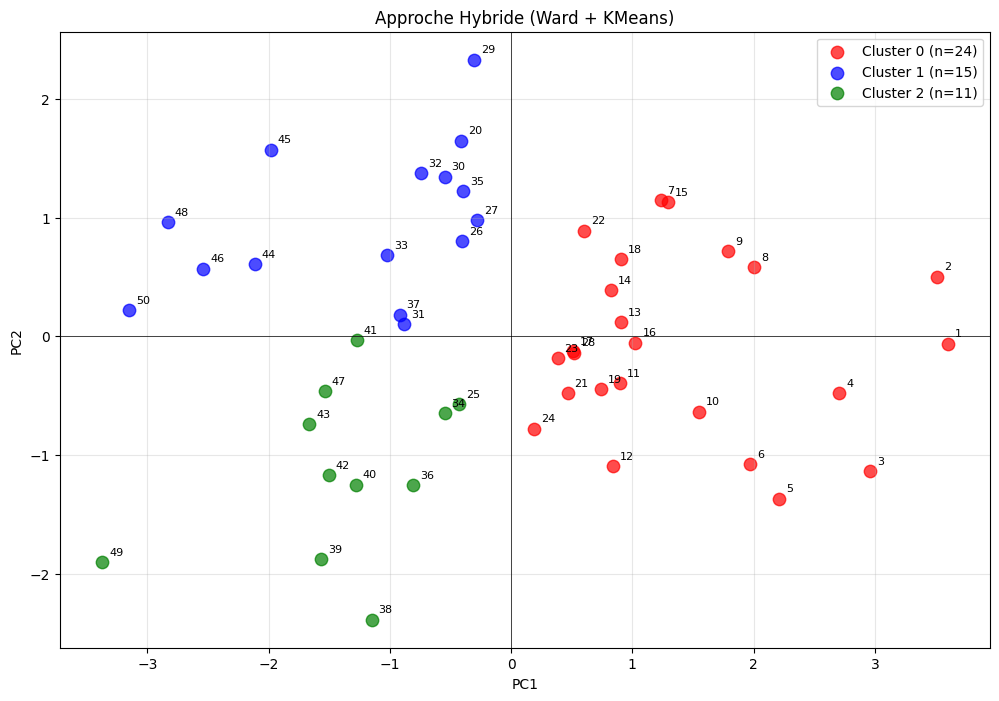

In [21]:
plot_clustering(X_pca, clustering_hyb, labels, 'Approche Hybride (Ward + KMeans)')

---
# Conclusion

1. **ACP** : 2 composantes capturent ~87% de la variance
2. **Interprétation** : PC1 = performance globale, PC2 = stratégie d'investissement
3. **Clustering** : 3 profils de startups identifiables
   - Haute performance (gros investissements, hauts bénéfices)
   - Performance moyenne
   - En développement (faibles investissements)
4. **Méthode recommandée** : Ward ou KMeans